Model loaded  |  device: cuda
Mask saved → 1_mask.png


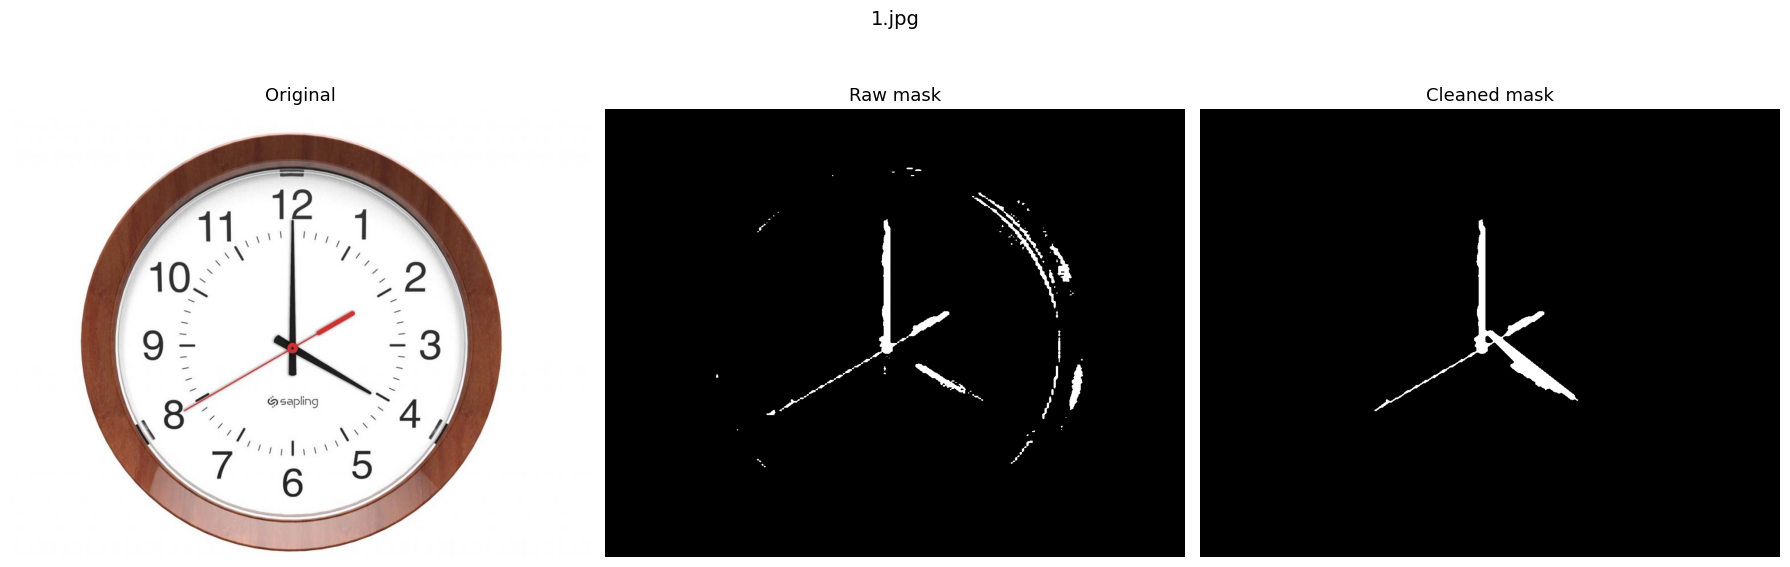

In [81]:
import cv2
import numpy as np
import torch
import torch.nn as nn
import torchvision.io as io
import torchvision.transforms.functional as TF
import matplotlib.pyplot as plt
from pathlib import Path

# =========================
# Config
# =========================
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
CHECKPOINT_PATH = "outputs/checkpoints/best_mask_unet.pth"

_MEAN = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
_STD  = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

def normalize(t):
    return (t - _MEAN) / _STD

# =========================
# Model
# =========================
class ResDoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False), nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False), nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
        )
        self.shortcut = nn.Conv2d(in_ch, out_ch, 1, bias=False) if in_ch != out_ch else nn.Identity()
    def forward(self, x): return self.block(x) + self.shortcut(x)

class MaskUNet(nn.Module):
    def __init__(self, base=64):
        super().__init__()
        self.pool = nn.MaxPool2d(2)
        self.e1 = ResDoubleConv(3,      base)
        self.e2 = ResDoubleConv(base,   base*2)
        self.e3 = ResDoubleConv(base*2, base*4)
        self.e4 = ResDoubleConv(base*4, base*8)
        self.bn = ResDoubleConv(base*8, base*16)
        self.up4, self.d4 = nn.ConvTranspose2d(base*16, base*8,  2, stride=2), ResDoubleConv(base*16, base*8)
        self.up3, self.d3 = nn.ConvTranspose2d(base*8,  base*4,  2, stride=2), ResDoubleConv(base*8,  base*4)
        self.up2, self.d2 = nn.ConvTranspose2d(base*4,  base*2,  2, stride=2), ResDoubleConv(base*4,  base*2)
        self.up1, self.d1 = nn.ConvTranspose2d(base*2,  base,    2, stride=2), ResDoubleConv(base*2,  base)
        self.head = nn.Sequential(nn.Conv2d(base, 1, 1), nn.Sigmoid())
    def forward(self, x):
        e1=self.e1(x); e2=self.e2(self.pool(e1)); e3=self.e3(self.pool(e2)); e4=self.e4(self.pool(e3))
        b=self.bn(self.pool(e4))
        d=self.d4(torch.cat([self.up4(b),e4],1))
        d=self.d3(torch.cat([self.up3(d),e3],1))
        d=self.d2(torch.cat([self.up2(d),e2],1))
        d=self.d1(torch.cat([self.up1(d),e1],1))
        return self.head(d)

# =========================
# Mask cleaning — center-anchor + straight-line bridge
# =========================
def clean_mask(
    raw_mask_uint8: np.ndarray,
    big_blob_size: int = 200,
    max_center_dist_ratio: float = 0.35,
    close_kernel: int = 7,
    bridge_thickness: int = 2,
) -> np.ndarray:
    """
    Center-anchor mask cleaning with straight-line bridging to the image center.

    Algorithm
    ---------
    1. Find the blob whose centroid is closest to the image center → the anchor.
       Kept unconditionally.

    2. For every other blob, keep it if BOTH:
         a) area >= big_blob_size
         b) centroid within max_center_dist_ratio * half_diagonal of the image center

    3. For each kept non-anchor blob, draw a straight line from its centroid
       directly to the image center. This bridges the gap along the natural
       direction a clock hand would point.

    4. Morphological closing smooths the result.
    """
    H, W = raw_mask_uint8.shape
    cx, cy    = W / 2.0, H / 2.0
    center_pt = (int(round(cx)), int(round(cy)))   # (col, row) for cv2.line
    half_diag = np.sqrt(cx**2 + cy**2)
    max_dist  = max_center_dist_ratio * half_diag

    num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(
        raw_mask_uint8, connectivity=8
    )

    if num_labels <= 1:
        return raw_mask_uint8.copy()

    # --- Step 1: find the anchor ---
    anchor_id, anchor_dist = -1, float("inf")
    for i in range(1, num_labels):
        bx, by = centroids[i]
        d = np.sqrt((bx - cx) ** 2 + (by - cy) ** 2)
        if d < anchor_dist:
            anchor_dist, anchor_id = d, i

    result = np.zeros_like(raw_mask_uint8)
    result[labels == anchor_id] = 255

    # --- Steps 2 & 3: qualify other blobs and draw a bridge to the image center ---
    for i in range(1, num_labels):
        if i == anchor_id:
            continue

        area   = stats[i, cv2.CC_STAT_AREA]
        bx, by = centroids[i]
        dist   = np.sqrt((bx - cx) ** 2 + (by - cy) ** 2)

        if area >= big_blob_size and dist <= max_dist:
            # Paint the blob
            result[labels == i] = 255

            # Draw a straight line from the blob's centroid to the image center
            blob_pt = (int(round(bx)), int(round(by)))   # (col, row)
            cv2.line(result, blob_pt, center_pt, color=255, thickness=bridge_thickness)

    # --- Step 4: morphological closing ---
    kernel  = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (close_kernel, close_kernel))
    cleaned = cv2.morphologyEx(result, cv2.MORPH_CLOSE, kernel)

    return cleaned


# =========================
# Full mask generation pipeline
# =========================
@torch.no_grad()
def generate_mask(
    image_path,
    threshold: float = 0.5,
    big_blob_size: int = 200,
    max_center_dist_ratio: float = 0.35,
    close_kernel: int = 7,
    bridge_thickness: int = 2,
    save_mask: bool = True,
) -> np.ndarray:
    model = MaskUNet(base=64).to(DEVICE)
    assert Path(CHECKPOINT_PATH).exists(), f"Checkpoint not found: {CHECKPOINT_PATH}"
    model.load_state_dict(torch.load(CHECKPOINT_PATH, map_location=DEVICE))
    model.eval()
    print(f"Model loaded  |  device: {DEVICE}")

    img_t = io.read_image(str(image_path))
    if img_t.shape[0] == 4:
        img_t = img_t[:3]
    img_float = img_t.float() / 255.0
    _, H, W = img_float.shape

    img_256  = TF.resize(img_float, [256, 256], antialias=True)
    x        = normalize(img_256).unsqueeze(0).to(DEVICE)
    prob_256 = model(x)
    prob     = TF.resize(prob_256, [H, W], interpolation=TF.InterpolationMode.BILINEAR)
    raw_mask = ((prob.squeeze() > threshold).float().cpu().numpy() * 255).astype(np.uint8)

    clean = clean_mask(
        raw_mask,
        big_blob_size=big_blob_size,
        max_center_dist_ratio=max_center_dist_ratio,
        close_kernel=close_kernel,
        bridge_thickness=bridge_thickness,
    )

    if save_mask:
        out_path = Path(image_path).with_stem(Path(image_path).stem + "_mask").with_suffix(".png")
        cv2.imwrite(str(out_path), clean)
        print(f"Mask saved → {out_path}")

    img_rgb = (img_float.permute(1, 2, 0).numpy() * 255).astype(np.uint8)
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    for ax, title, im, cmap in zip(
        axes,
        ["Original", "Raw mask", "Cleaned mask"],
        [img_rgb, raw_mask, clean],
        [None, "gray", "gray"],
    ):
        ax.imshow(im, cmap=cmap)
        ax.set_title(title, fontsize=13)
        ax.axis("off")
    plt.suptitle(Path(image_path).name, fontsize=14, y=1.01)
    plt.tight_layout()
    plt.show()

    return clean


# =========================
# Run
# =========================
if __name__ == "__main__":
    IMAGE_PATH = "1.jpg"

    mask = generate_mask(
        IMAGE_PATH,
        threshold=0.5,
        big_blob_size=30,
        max_center_dist_ratio=0.35,
        close_kernel=7,
        bridge_thickness=10,
        save_mask = True
    )